<a href="https://colab.research.google.com/github/vinicius-mattoso/industrial-rul-predictive-maintenance/blob/main/notebooks/01_rul_eda_and_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUL Estimation com NASA CMAPSS

Neste notebook vamos construir um projeto de **Remaining Useful Life (RUL)** aplicado à manutenção preditiva de equipamentos.

O objetivo é estimar quantos ciclos de operação ainda restam antes da falha de um motor, usando dados simulados do dataset NASA CMAPSS.

Além da modelagem, vamos incluir uma camada de **guard rails operacionais**, ou seja, regras inspiradas em limites técnicos/manuais de operação para apoiar a decisão de manutenção.

https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data/resource/5224bcd1-ad61-490b-93b9-2817288accb8

In [1]:
!pip install xgboost shap

In [2]:
import os
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)

sns.set_theme(style="whitegrid")

## 1. Carregamento dos dados

Vamos usar o subconjunto **FD001** do NASA CMAPSS.

Esse subconjunto é um bom ponto de partida porque possui:
- uma condição operacional;
- um modo de falha;
- múltiplos motores;
- sensores medidos ao longo dos ciclos de vida.

Cada motor é observado até a falha. Portanto, o último ciclo disponível de cada motor representa o ponto em que sua vida útil chegou ao fim.

In [10]:
from google.colab import files

uploaded = files.upload()

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [11]:
index_columns = ["unit_number", "time_in_cycles"]

setting_columns = [f"setting_{i}" for i in range(1, 4)]

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

columns = index_columns + setting_columns + sensor_columns

print("Total de colunas:", len(columns))
columns

Total de colunas: 26


['unit_number',
 'time_in_cycles',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [12]:
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

rul_test = pd.read_csv(
    "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["true_rul"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL test shape:", rul_test.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL test shape: (100, 1)


# 2. Exploratory Data Analysis (EDA)

Antes da modelagem, precisamos entender:
- o comportamento operacional dos motores;
- a distribuição dos sensores;
- possíveis padrões de degradação;
- variabilidade operacional;
- sensores com potencial informativo.

Essa etapa é fundamental em projetos industriais, pois o entendimento físico e operacional dos dados costuma ser tão importante quanto o próprio modelo de Machine Learning.

In [13]:
train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
test_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [15]:
rul_test.head()

,true_rul
0,112
1,98
2,69
3,82
4,91


In [18]:
print("Motores no treino:", train_df["unit_number"].nunique())
print("Motores no teste:", test_df["unit_number"].nunique())

# print("\nCiclos no treino:")
# display(train_df.groupby("unit_number")["time_in_cycles"].max().describe())

# print("\nCiclos no teste:")
# display(test_df.groupby("unit_number")["time_in_cycles"].max().describe())

Motores no treino: 100
Motores no teste: 100


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   setting_1       20631 non-null  float64
 3   setting_2       20631 non-null  float64
 4   setting_3       20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [19]:
train_df.describe()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## Vida útil observada por motor

Cada motor possui uma trajetória operacional diferente até a falha.

Essa variabilidade é importante porque o modelo precisa aprender padrões gerais de degradação e não apenas memorizar ciclos específicos.

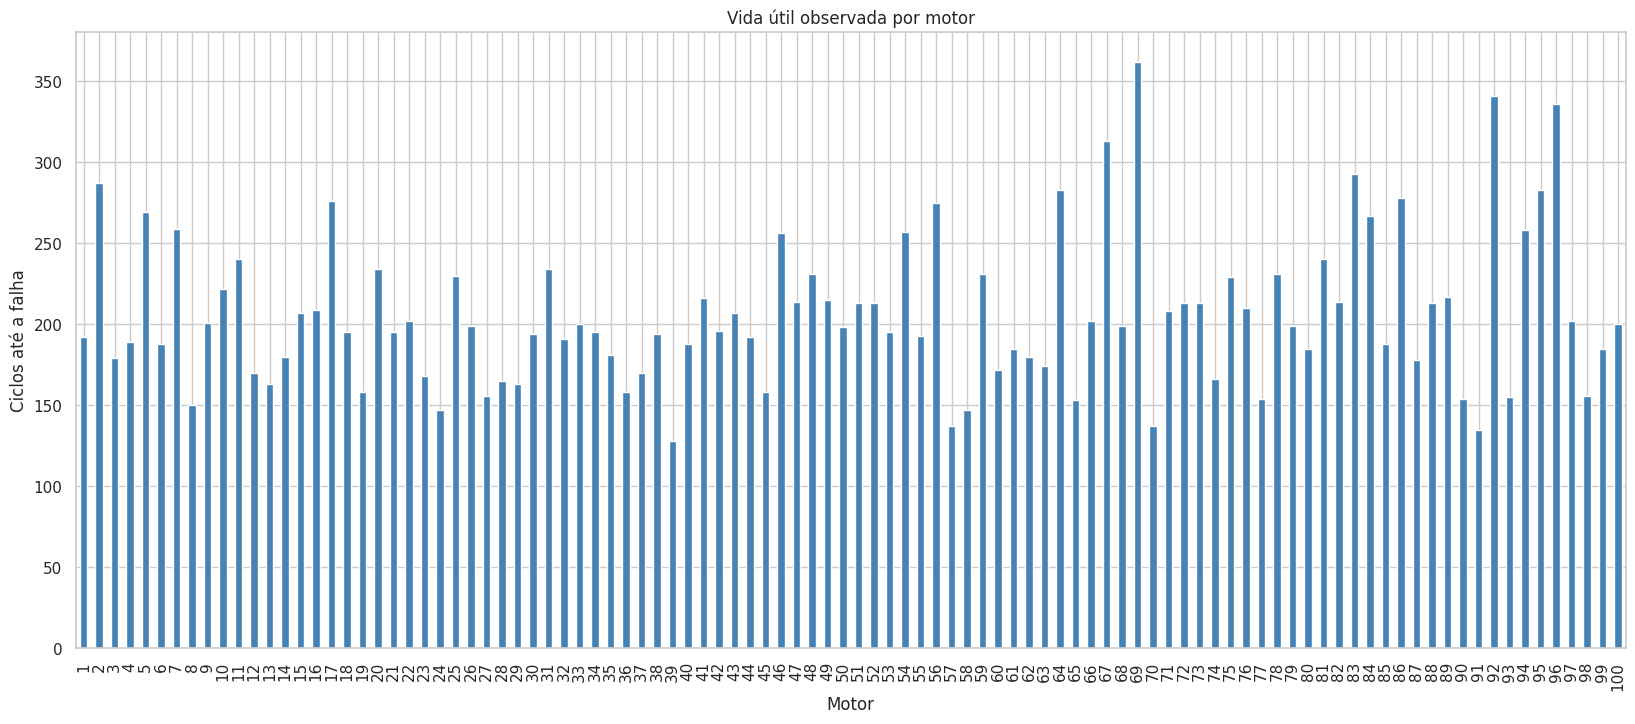

In [21]:
life_per_engine = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
)

plt.figure(figsize=(20, 8))

life_per_engine.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Vida útil observada por motor")
plt.xlabel("Motor")
plt.ylabel("Ciclos até a falha")

plt.show()

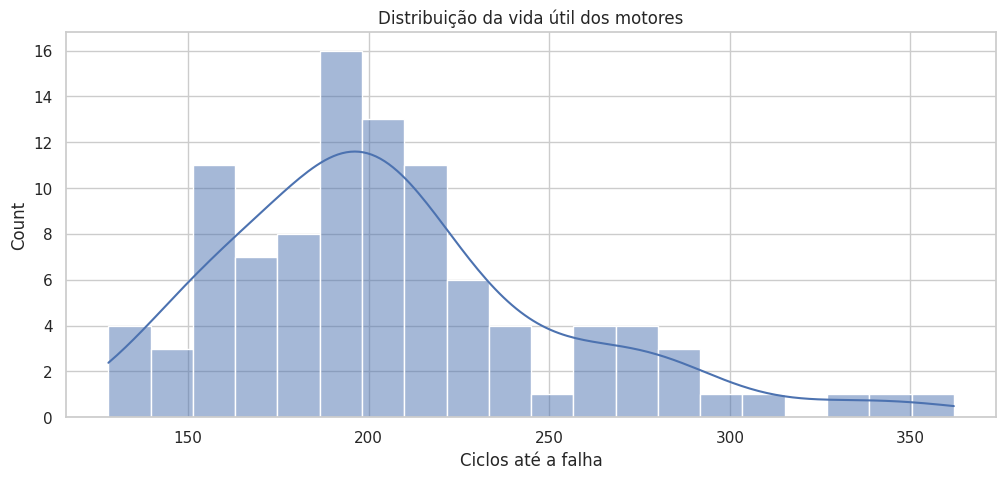

In [22]:
plt.figure(figsize=(12, 5))

sns.histplot(
    life_per_engine,
    bins=20,
    kde=True
)

plt.title("Distribuição da vida útil dos motores")
plt.xlabel("Ciclos até a falha")

plt.show()

## Qualidade dos dados

Em ambientes industriais reais é comum encontrarmos:
- falhas de telemetria;
- sensores ausentes;
- perda de comunicação;
- leituras inconsistentes.

Vamos validar rapidamente a integridade dos dados.

In [23]:
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0]

,0


## Distribuição dos sensores

Vamos analisar a distribuição de alguns sensores para entender:
- dispersão;
- presença de outliers;
- comportamento operacional.

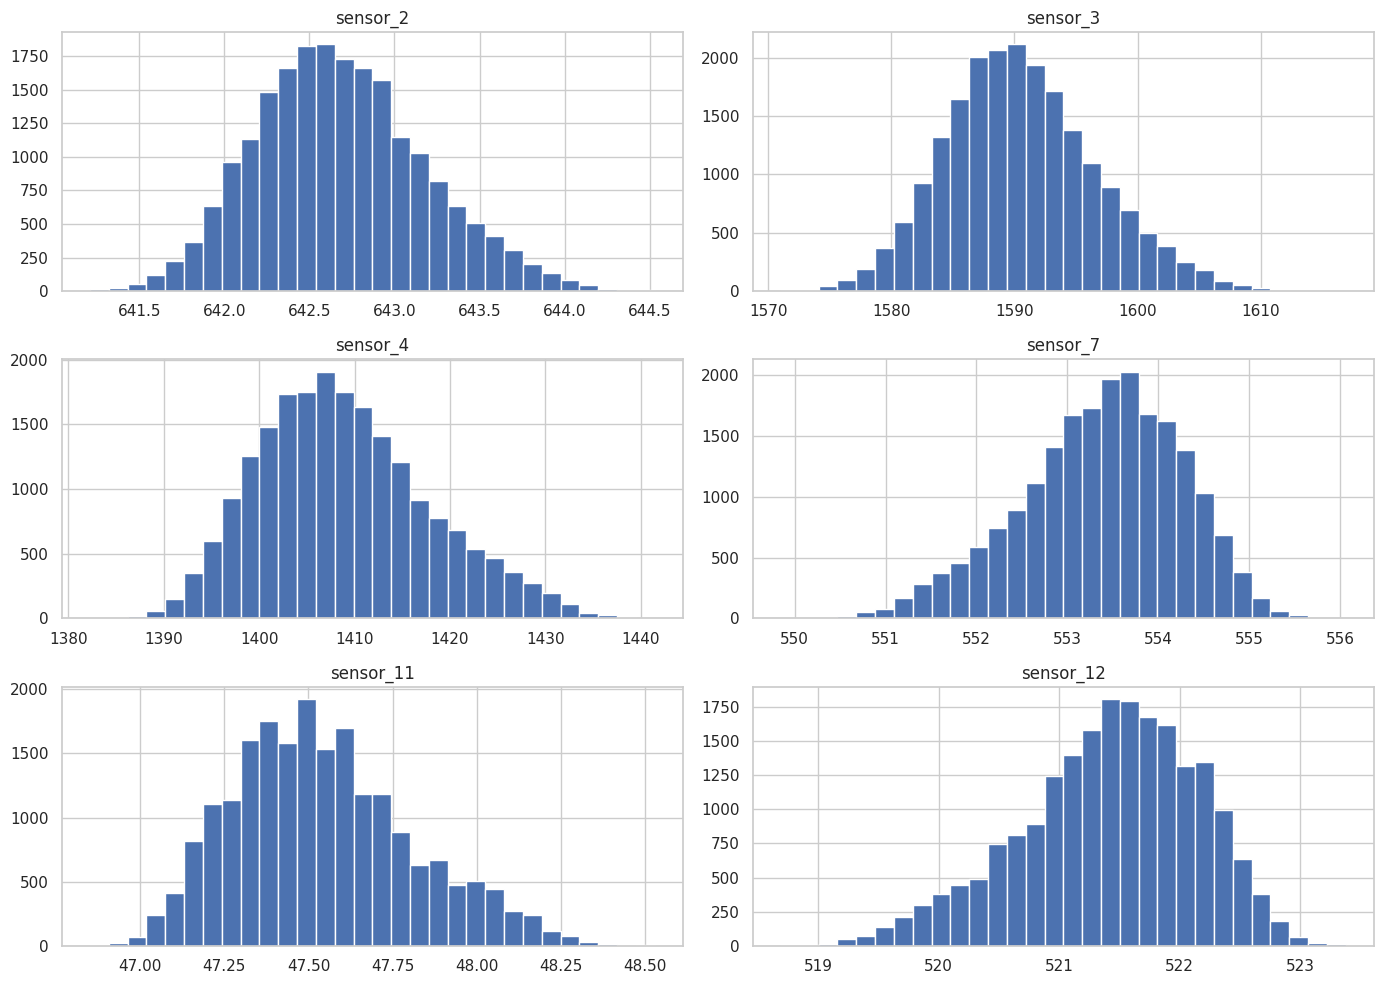

In [24]:
selected_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12"
]

train_df[selected_sensors].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

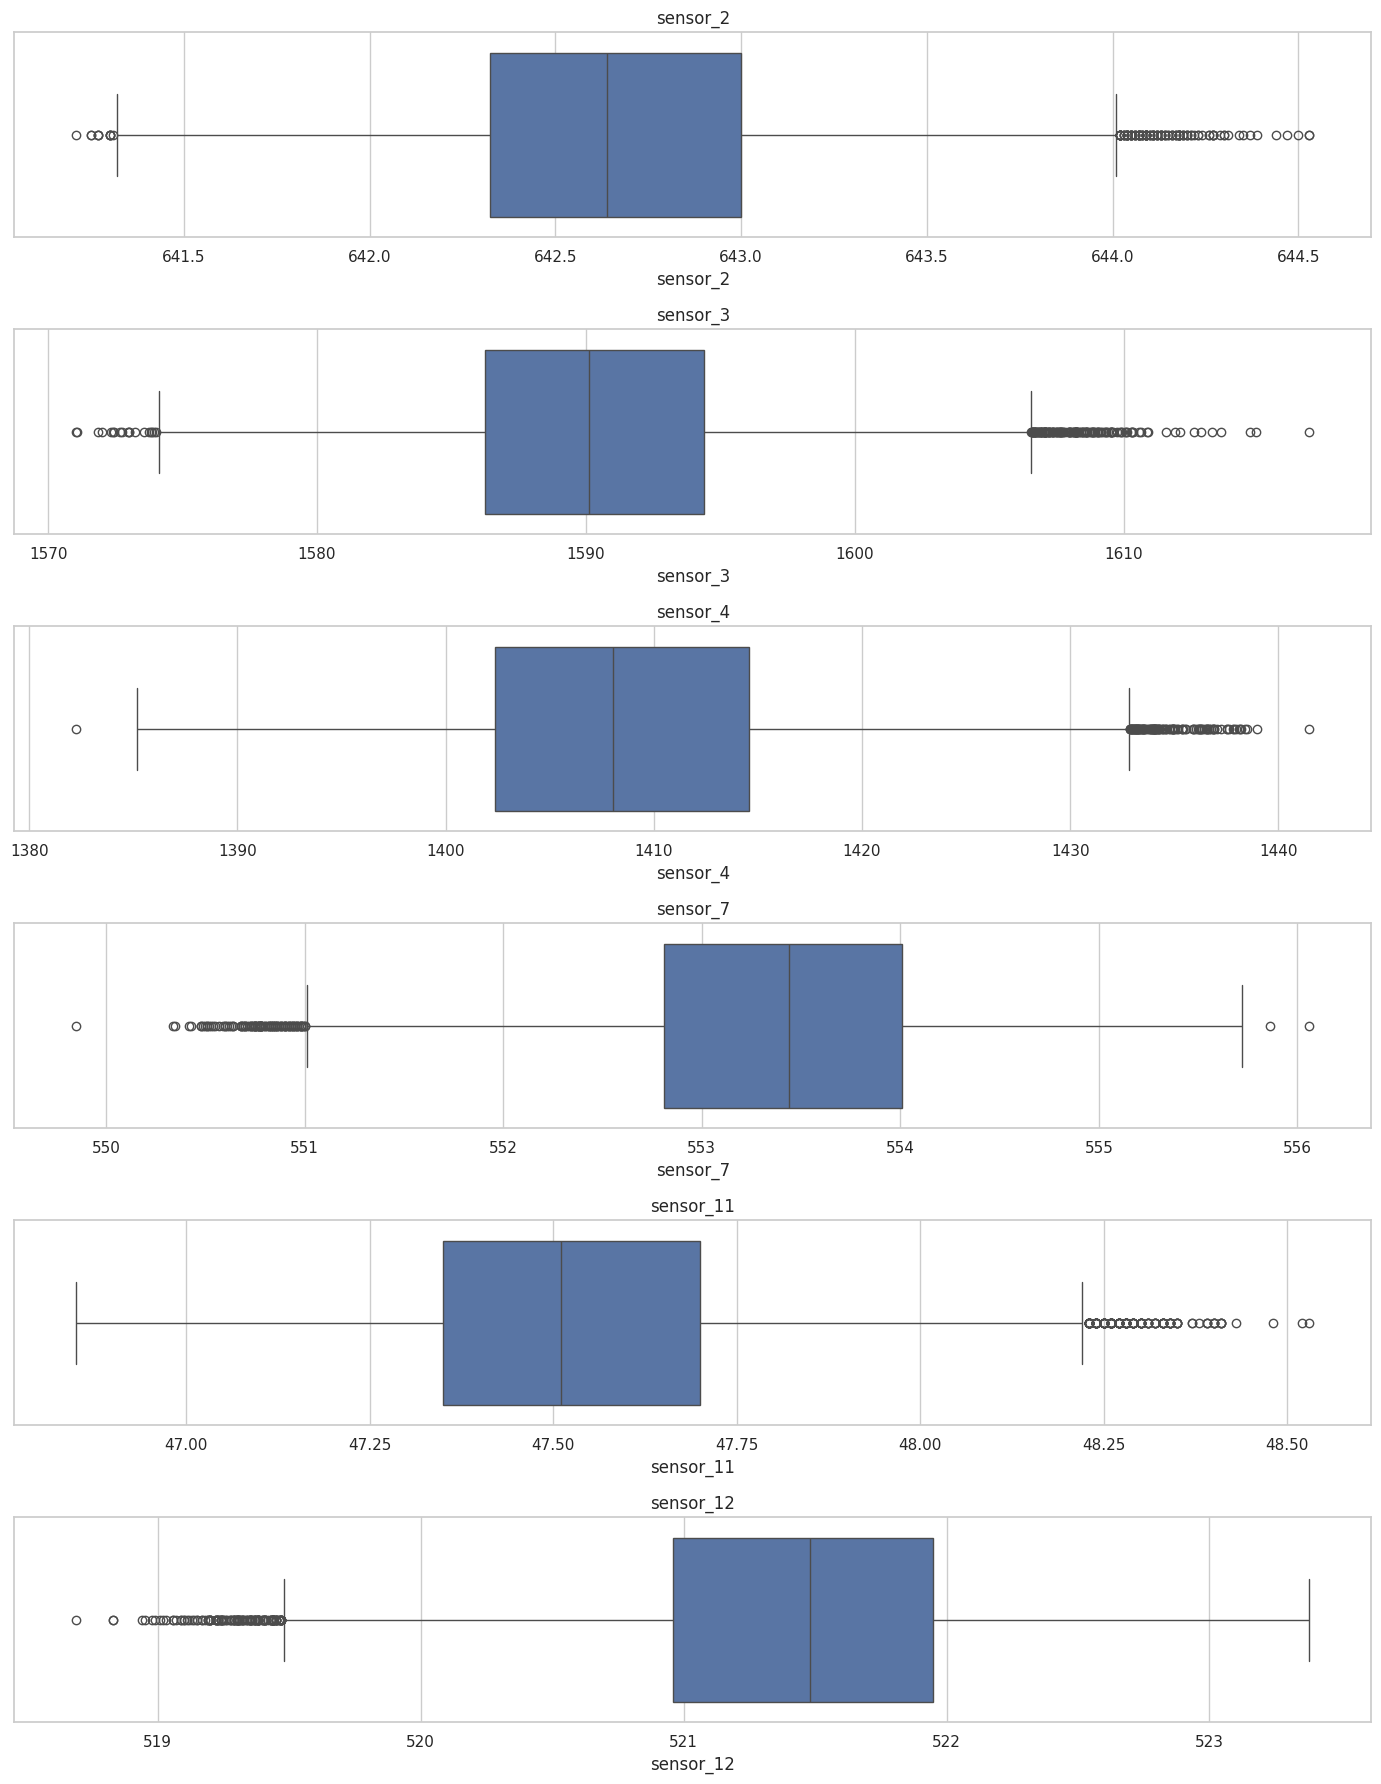

In [25]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(14, 18)
)

for i, sensor in enumerate(selected_sensors):

    sns.boxplot(
        x=train_df[sensor],
        ax=axes[i]
    )

    axes[i].set_title(sensor)

plt.tight_layout()
plt.show()

## Correlação entre sensores

Sensores altamente correlacionados podem:
- representar redundância operacional;
- indicar variáveis fisicamente relacionadas;
- impactar feature selection.

In [26]:
correlation_matrix = train_df[sensor_columns].corr()

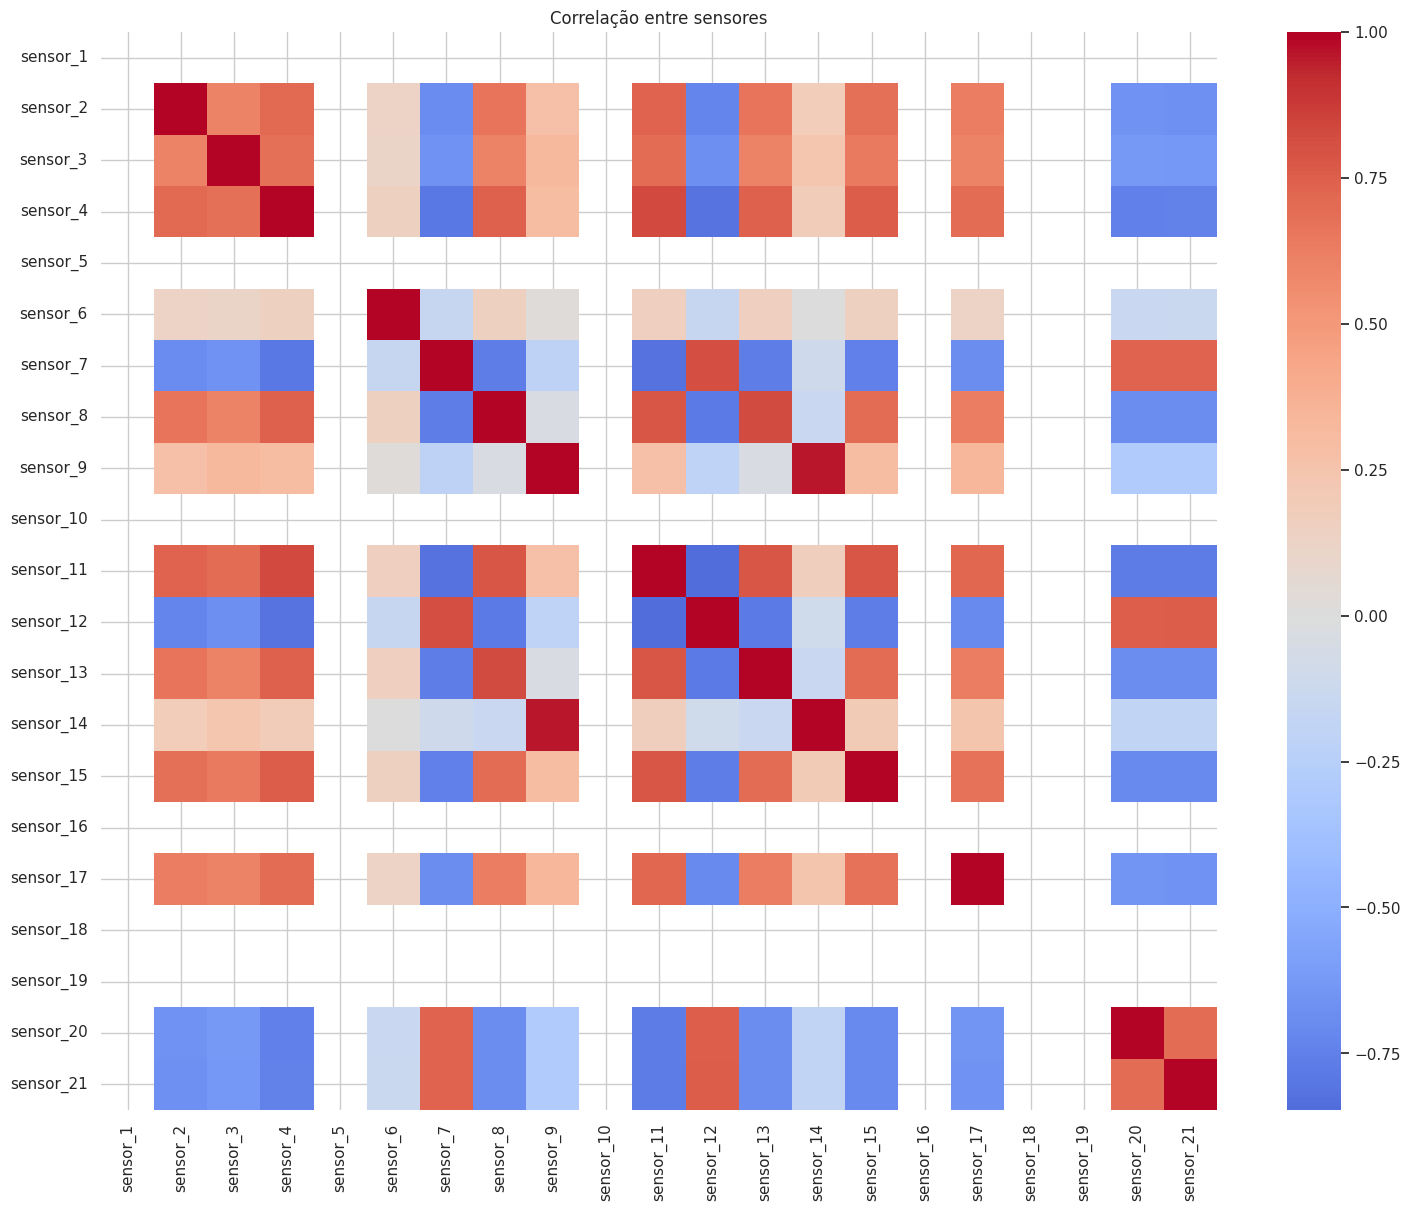

In [27]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre sensores")

plt.show()

## Sensores com baixa variabilidade

Sensores praticamente constantes tendem a possuir baixa capacidade preditiva.

Esse comportamento é muito comum em sistemas industriais reais, onde parte da instrumentação opera em regime quase estacionário.

In [28]:
sensor_variance = (
    train_df[sensor_columns]
    .var()
    .sort_values()
)

sensor_variance

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


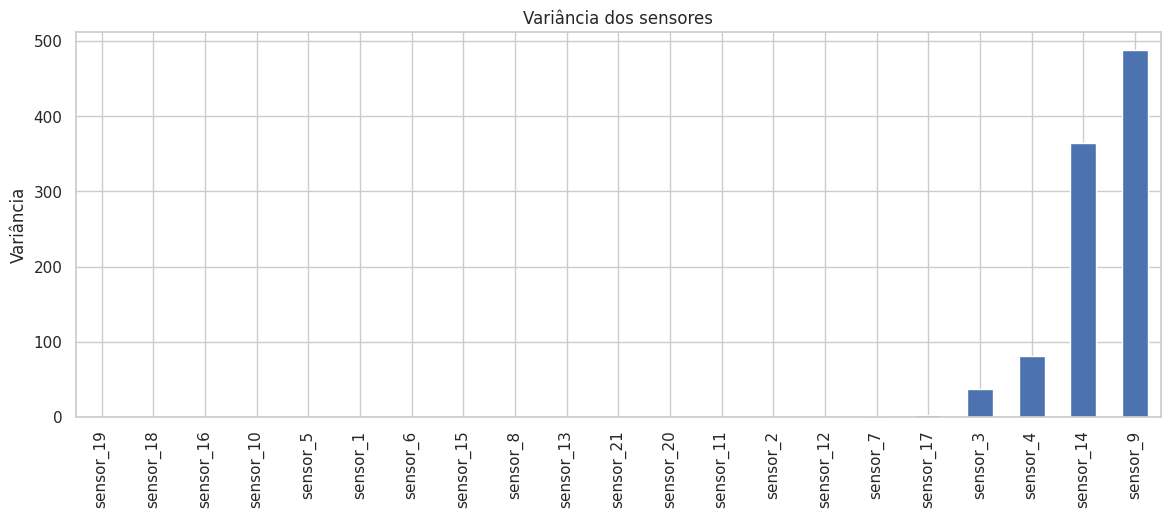

In [29]:
plt.figure(figsize=(14, 5))

sensor_variance.plot(kind="bar")

plt.title("Variância dos sensores")
plt.ylabel("Variância")

plt.show()

## Trajetória operacional dos sensores

Agora vamos observar como os sensores evoluem ao longo dos ciclos de operação.

Essa análise é importante para identificar:
- tendências de degradação;
- aumento de variabilidade;
- mudanças operacionais próximas da falha.

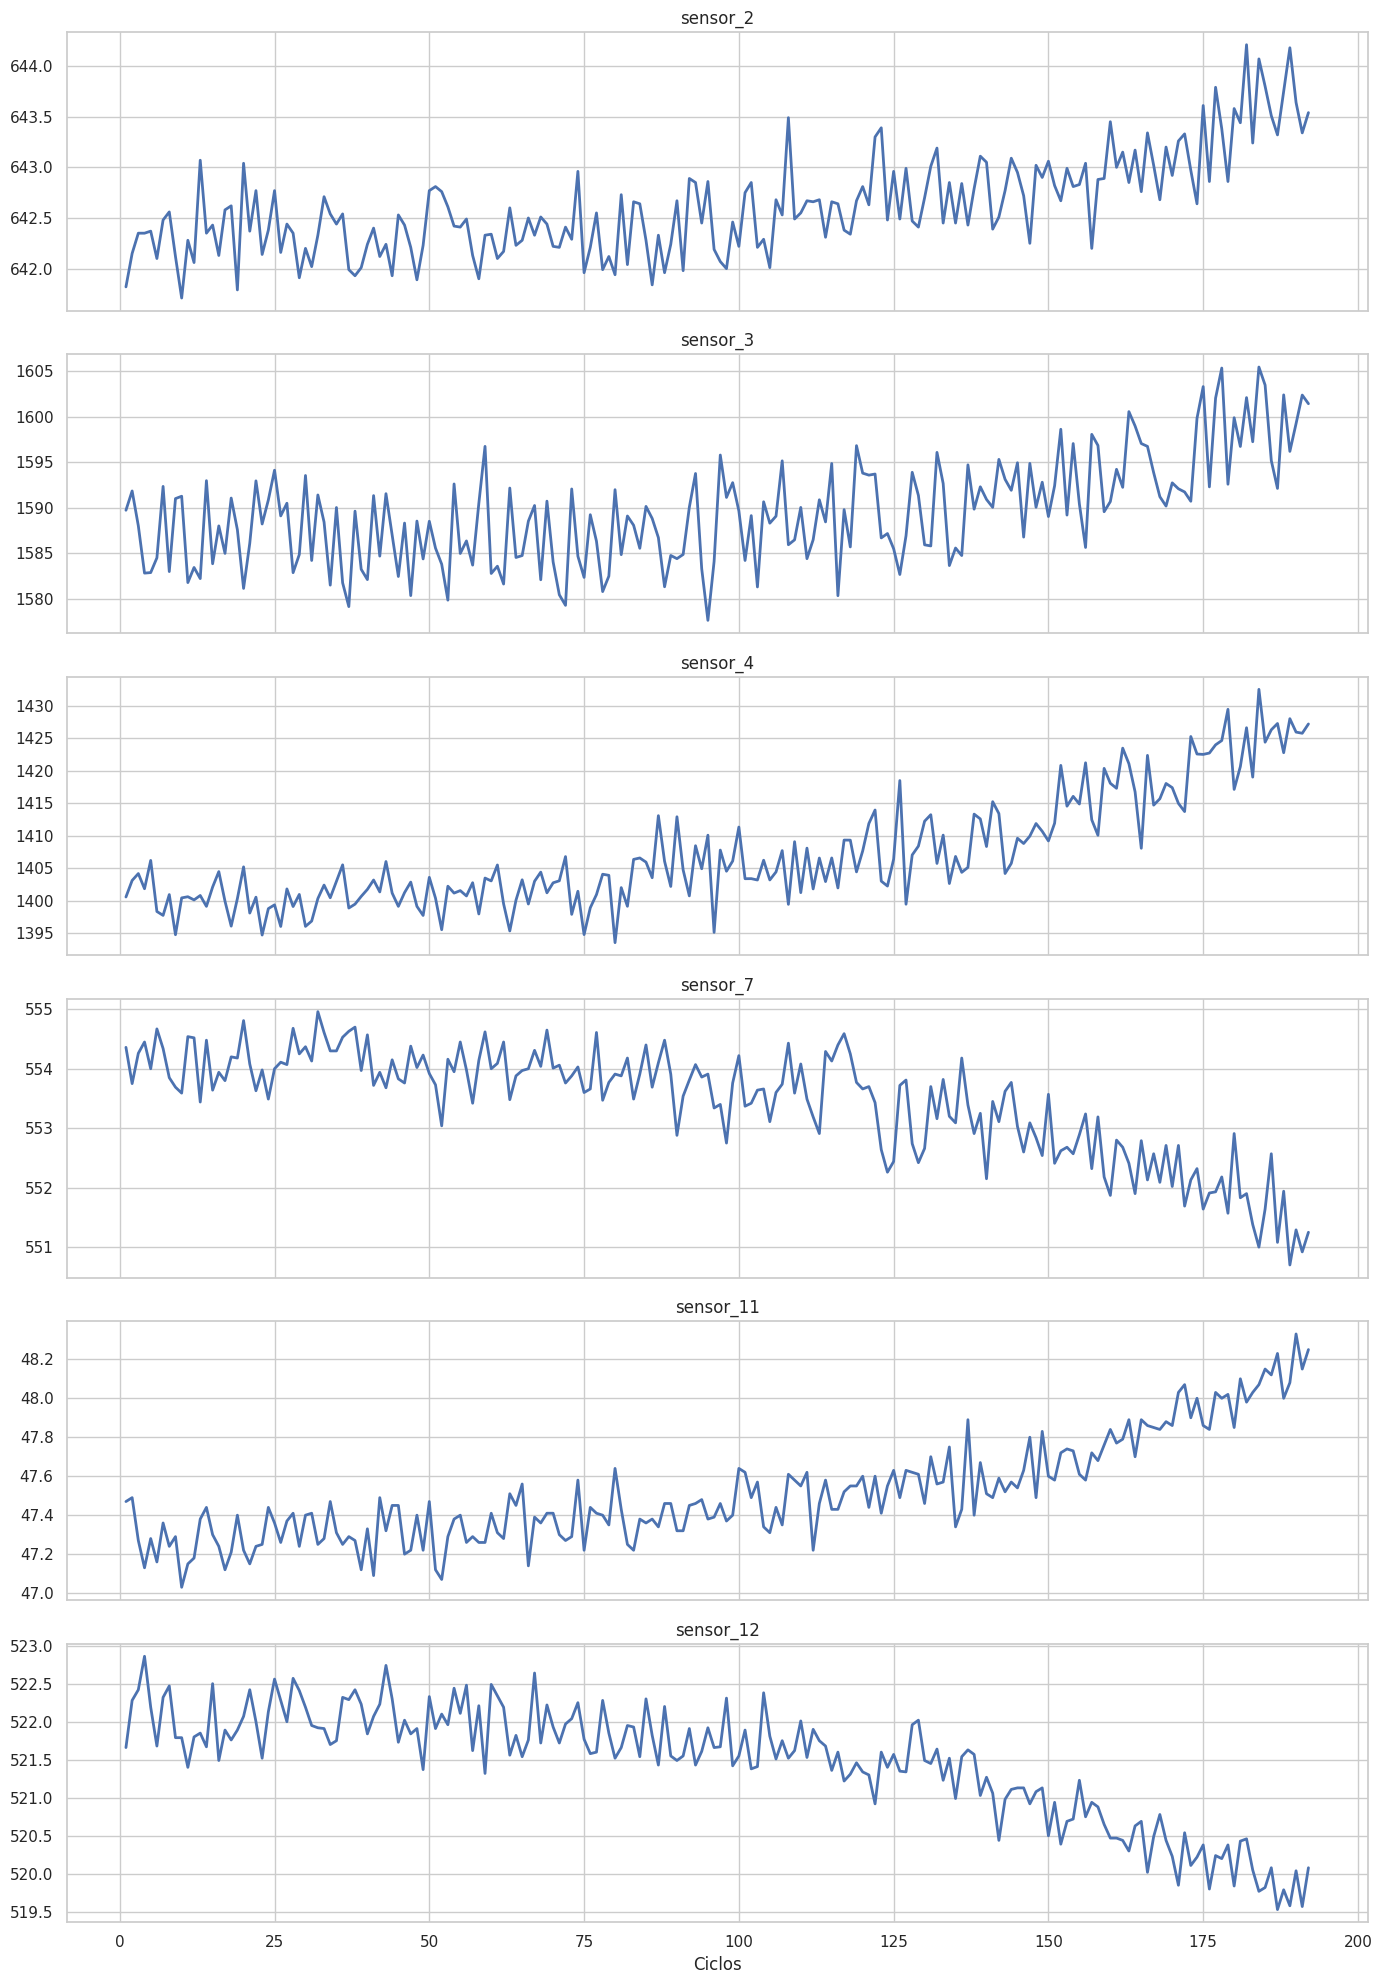

In [30]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(14, 20),
    sharex=True
)

for i, sensor in enumerate(selected_sensors):

    axes[i].plot(
        engine_df["time_in_cycles"],
        engine_df[sensor],
        linewidth=2
    )

    axes[i].set_title(sensor)

plt.xlabel("Ciclos")

plt.tight_layout()
plt.show()

# 3. Construção do Remaining Useful Life (RUL)

O Remaining Useful Life (RUL) representa quantos ciclos de operação ainda restam até a falha do equipamento.

Como os motores do conjunto de treino são observados até a falha, conseguimos calcular diretamente o RUL utilizando:

RUL = ciclo_final - ciclo_atual

Esse target será a principal variável utilizada pelos modelos de Machine Learning.

## Encontrando o ciclo final de cada motor

In [31]:
max_cycles = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
    .reset_index()
)

max_cycles.columns = [
    "unit_number",
    "max_cycle"
]

max_cycles.head()

,unit_number,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [32]:
train_df = train_df.merge(
    max_cycles,
    on="unit_number",
    how="left"
)

train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [33]:
train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [34]:
train_df[
    [
        "unit_number",
        "time_in_cycles",
        "max_cycle",
        "RUL"
    ]
].head(15)

,unit_number,time_in_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


## Curva de degradação

Agora vamos observar como o RUL decai ao longo dos ciclos operacionais.

Essa curva representa o processo de envelhecimento do equipamento ao longo da operação.

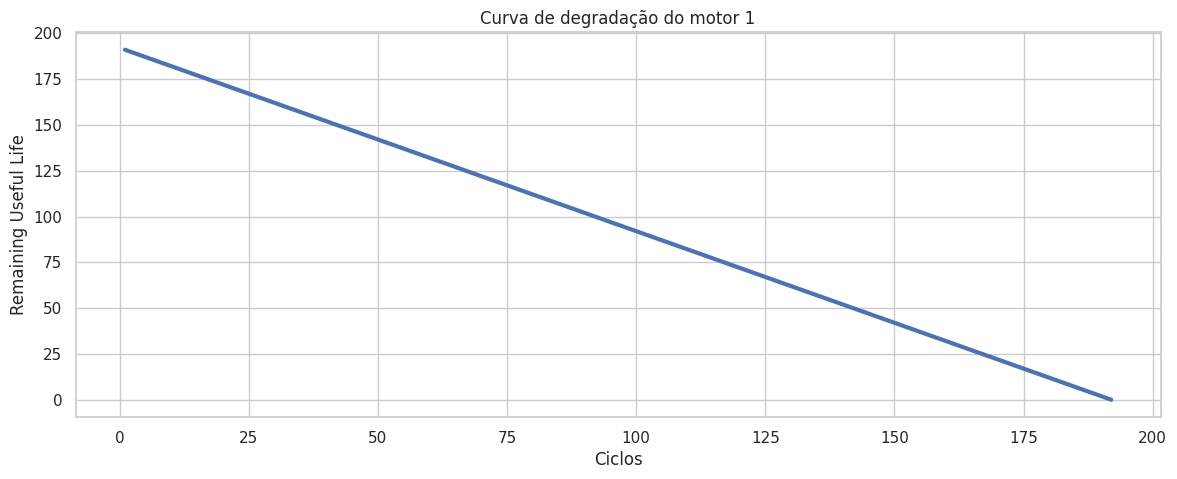

In [35]:
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

plt.plot(
    engine_df["time_in_cycles"],
    engine_df["RUL"],
    linewidth=3
)

plt.title(
    f"Curva de degradação do motor {engine_id}"
)

plt.xlabel("Ciclos")
plt.ylabel("Remaining Useful Life")

plt.show()

## Distribuição do RUL

A distribuição do RUL ajuda a entender:
- concentração de estados saudáveis;
- quantidade de amostras próximas da falha;
- desbalanceamento temporal do dataset.

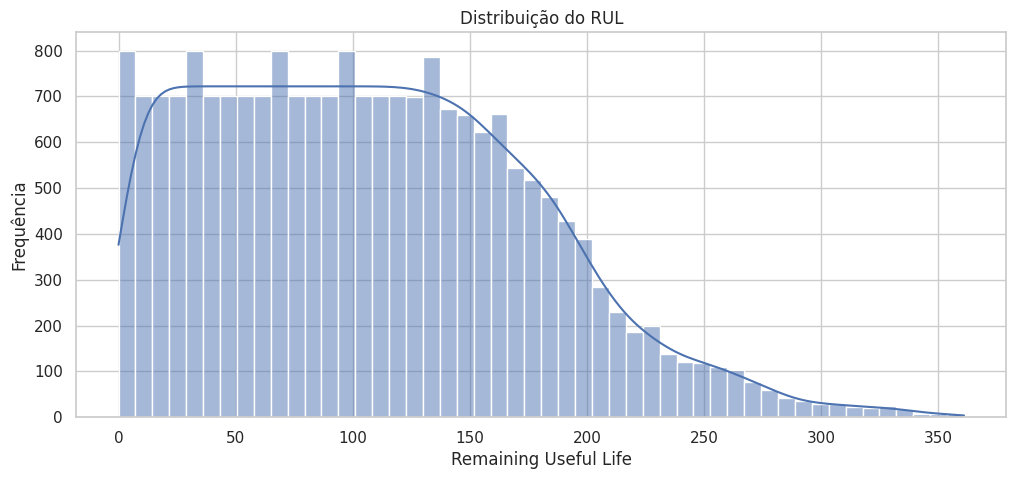

In [36]:
plt.figure(figsize=(12, 5))

sns.histplot(
    train_df["RUL"],
    bins=50,
    kde=True
)

plt.title("Distribuição do RUL")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Frequência")

plt.show()

## Aplicando limite superior no RUL

Em muitos projetos industriais, valores muito altos de RUL possuem baixa relevância operacional.

Por isso, é comum aplicar um limite máximo no target, focando o modelo na região mais crítica da degradação.

In [37]:
RUL_CAP = 125

train_df["RUL_capped"] = (
    train_df["RUL"]
    .clip(upper=RUL_CAP)
)

train_df[
    [
        "RUL",
        "RUL_capped"
    ]
].head()

,RUL,RUL_capped
0,191,125
1,190,125
2,189,125
3,188,125
4,187,125


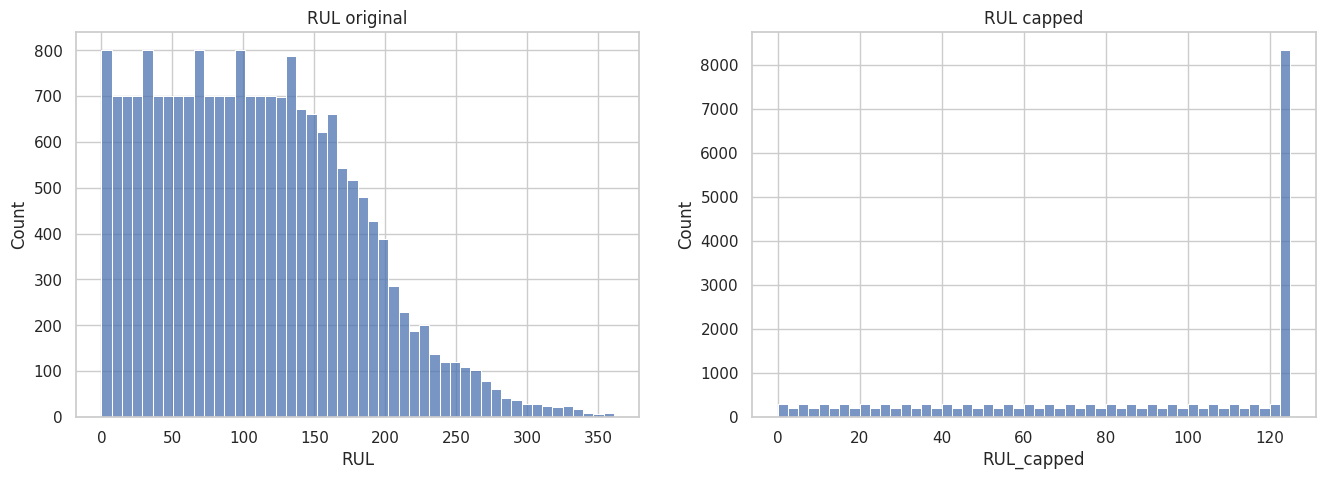

In [38]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

sns.histplot(
    train_df["RUL"],
    bins=50,
    ax=ax[0]
)

ax[0].set_title("RUL original")

sns.histplot(
    train_df["RUL_capped"],
    bins=50,
    ax=ax[1]
)

ax[1].set_title("RUL capped")

plt.show()

## Estados de saúde do equipamento

Além da regressão do RUL, também podemos interpretar o equipamento em diferentes estados operacionais.

Isso ajuda na criação de:
- alarmes;
- priorização;
- manutenção baseada em condição.

In [39]:
def health_state(rul):

    if rul > 80:
        return "Healthy"

    elif rul > 40:
        return "Degrading"

    else:
        return "Critical"

In [40]:
train_df["health_state"] = (
    train_df["RUL_capped"]
    .apply(health_state)
)

train_df[
    [
        "RUL_capped",
        "health_state"
    ]
].head()

,RUL_capped,health_state
0,125,Healthy
1,125,Healthy
2,125,Healthy
3,125,Healthy
4,125,Healthy


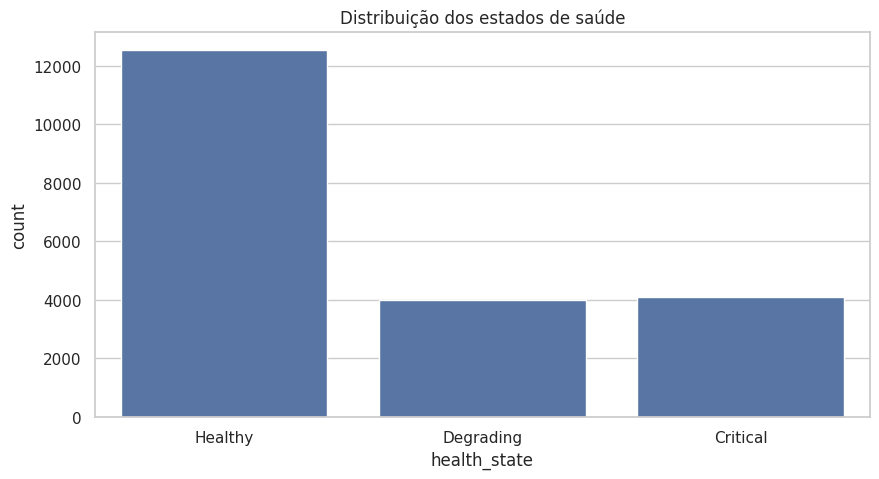

In [41]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="health_state",
    order=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.title("Distribuição dos estados de saúde")

plt.show()

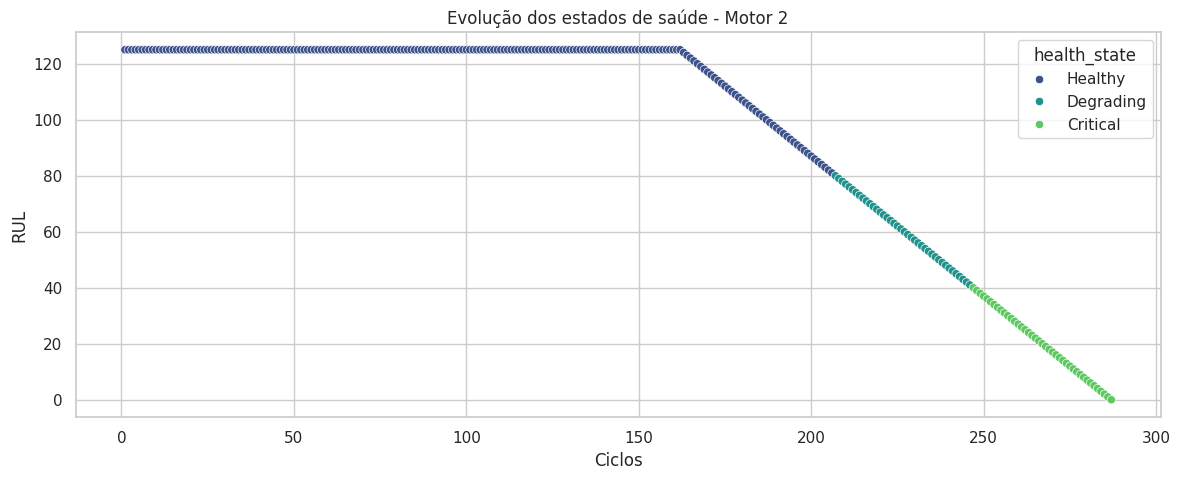

In [43]:
engine_id = 2

engine_df = train_df[
    train_df["unit_number"] == engine_id
]

plt.figure(figsize=(14, 5))

sns.scatterplot(
    data=engine_df,
    x="time_in_cycles",
    y="RUL_capped",
    hue="health_state",
    palette="viridis"
)

plt.title(
    f"Evolução dos estados de saúde - Motor {engine_id}"
)

plt.xlabel("Ciclos")
plt.ylabel("RUL")

plt.show()